# 02. Exploratory Data Analysis

Notebook này ghi lại kết quả của **Giai đoạn 2 — EDA**.

Vai trò của notebook:

- Không chạy lại toàn bộ pipeline EDA.
- Đọc các bảng và hình đã sinh ra từ `scripts/run_eda.py`.
- Phân tích phân bố nhãn, độ dài văn bản và độ dài PhoBERT subword.
- Ghi nhận quyết định kỹ thuật trước khi sang baseline và PhoBERT.

Input chính:

```text
data/processed/all_standardized.csv
```

Output phân tích:

```text
outputs/tables/
outputs/figures/
outputs/reports/eda_report.md
```

## 1. Setup

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd

print("Project root:", ROOT)

TABLES_DIR = ROOT / "outputs" / "tables"
FIGURES_DIR = ROOT / "outputs" / "figures"
REPORTS_DIR = ROOT / "outputs" / "reports"
PROCESSED_DIR = ROOT / "data" / "processed"

Project root: d:\project-ml-engineering\viedufeedback-robust


## 2. Kiểm tra file EDA bắt buộc

In [2]:
required_files = {
    "all_standardized": PROCESSED_DIR / "all_standardized.csv",
    "basic_summary": TABLES_DIR / "eda_basic_summary.csv",
    "sentiment_distribution": TABLES_DIR / "eda_label_distribution_sentiment.csv",
    "topic_distribution": TABLES_DIR / "eda_label_distribution_topic.csv",
    "text_length_percentiles": TABLES_DIR / "text_length_percentiles.csv",
    "subword_percentiles": TABLES_DIR / "phobert_subword_length_percentiles.csv",
    "max_length_recommendation": TABLES_DIR / "max_length_recommendation.csv",
    "sentiment_figure": FIGURES_DIR / "sentiment_distribution.png",
    "topic_figure": FIGURES_DIR / "topic_distribution.png",
    "subword_figure": FIGURES_DIR / "phobert_subword_count_distribution.png",
}

check_df = pd.DataFrame(
    [{"name": name, "path": str(path), "exists": path.exists()} for name, path in required_files.items()]
)

display(check_df)

missing = check_df.loc[~check_df["exists"], "name"].tolist()
if missing:
    raise FileNotFoundError(f"Missing required EDA files: {missing}")

print("All required Stage 2 files exist.")

,name,path,exists
0,all_standardized,d:\project-ml-engineering\viedufeedback-robust...,True
1,basic_summary,d:\project-ml-engineering\viedufeedback-robust...,True
2,sentiment_distribution,d:\project-ml-engineering\viedufeedback-robust...,True
3,topic_distribution,d:\project-ml-engineering\viedufeedback-robust...,True
4,text_length_percentiles,d:\project-ml-engineering\viedufeedback-robust...,True
5,subword_percentiles,d:\project-ml-engineering\viedufeedback-robust...,True
6,max_length_recommendation,d:\project-ml-engineering\viedufeedback-robust...,True
7,sentiment_figure,d:\project-ml-engineering\viedufeedback-robust...,True
8,topic_figure,d:\project-ml-engineering\viedufeedback-robust...,True
9,subword_figure,d:\project-ml-engineering\viedufeedback-robust...,True


All required Stage 2 files exist.


## 3. Basic summary

Mục tiêu: kiểm tra số mẫu, text rỗng, duplicate và số lớp của từng task.

In [3]:
basic_summary = pd.read_csv(TABLES_DIR / "eda_basic_summary.csv")
display(basic_summary)

,split,num_rows,num_unique_text,empty_text,duplicated_text,sentiment_num_classes,topic_num_classes
0,test,3166,3166,0,0,3,4
1,train,11426,11425,0,1,3,4
2,validation,1583,1583,0,0,3,4
3,all,16175,16174,0,1,3,4


## 4. Sentiment label distribution

Mục tiêu: kiểm tra mức mất cân bằng giữa `negative`, `neutral`, `positive`.

,split,label_id,label_name,count,percent
0,test,0,negative,1409,44.5041
1,test,1,neutral,167,5.2748
2,test,2,positive,1590,50.2211
3,train,0,negative,5325,46.6042
4,train,1,neutral,458,4.0084
5,train,2,positive,5643,49.3874
6,validation,0,negative,705,44.5357
7,validation,1,neutral,73,4.6115
8,validation,2,positive,805,50.8528


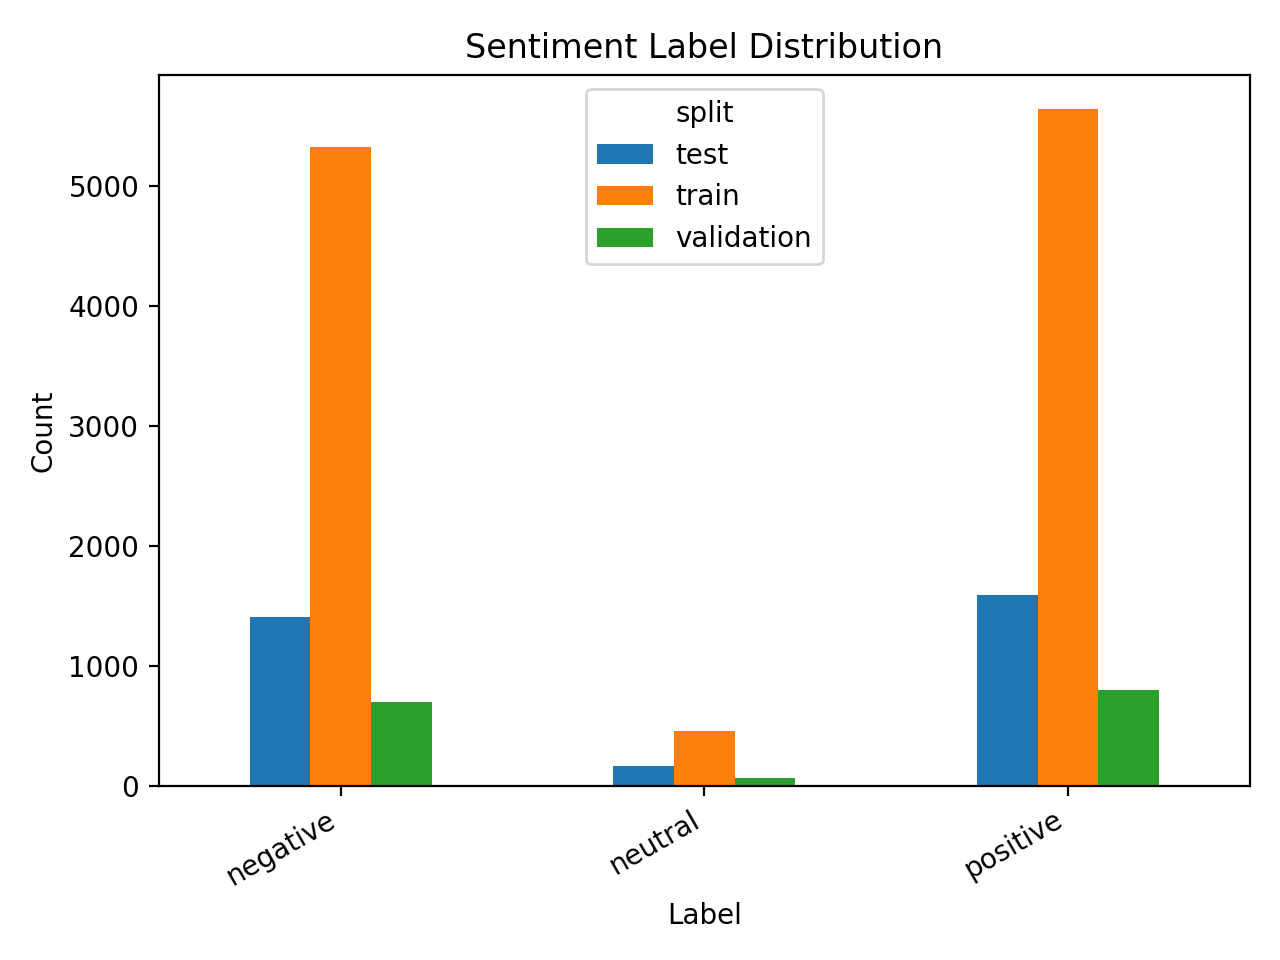

In [4]:
sentiment_dist = pd.read_csv(TABLES_DIR / "eda_label_distribution_sentiment.csv")
display(sentiment_dist)
display(Image(filename=str(FIGURES_DIR / "sentiment_distribution.png")))

### Nhận xét sentiment

Cần chú ý lớp `neutral`. Nếu tỷ lệ lớp này rất nhỏ, Accuracy sẽ không đủ đáng tin. Khi đó, Macro-F1 và per-class F1 phải được dùng làm metric chính.

In [5]:
sentiment_pivot = sentiment_dist.pivot(index="split", columns="label_name", values="percent")
display(sentiment_pivot)

if "neutral" in sentiment_pivot.columns:
    neutral_rates = sentiment_pivot["neutral"]
    display(Markdown(f"Neutral percent range: **{neutral_rates.min():.2f}% - {neutral_rates.max():.2f}%**"))

label_name,negative,neutral,positive
split,,,
test,44.5041,5.2748,50.2211
train,46.6042,4.0084,49.3874
validation,44.5357,4.6115,50.8528


Neutral percent range: **4.01% - 5.27%**

## 5. Topic label distribution

Mục tiêu: kiểm tra mức mất cân bằng giữa `lecturer`, `training_program`, `facility`, `others`.

,split,label_id,label_name,count,percent
0,test,0,lecturer,2290,72.3310
1,test,1,training_program,572,18.0670
2,test,2,facility,145,4.5799
3,test,3,others,159,5.0221
4,train,0,lecturer,8166,71.4686
5,train,1,training_program,2201,19.2631
6,train,2,facility,497,4.3497
7,train,3,others,562,4.9186
8,validation,0,lecturer,1151,72.7100
9,validation,1,training_program,267,16.8667


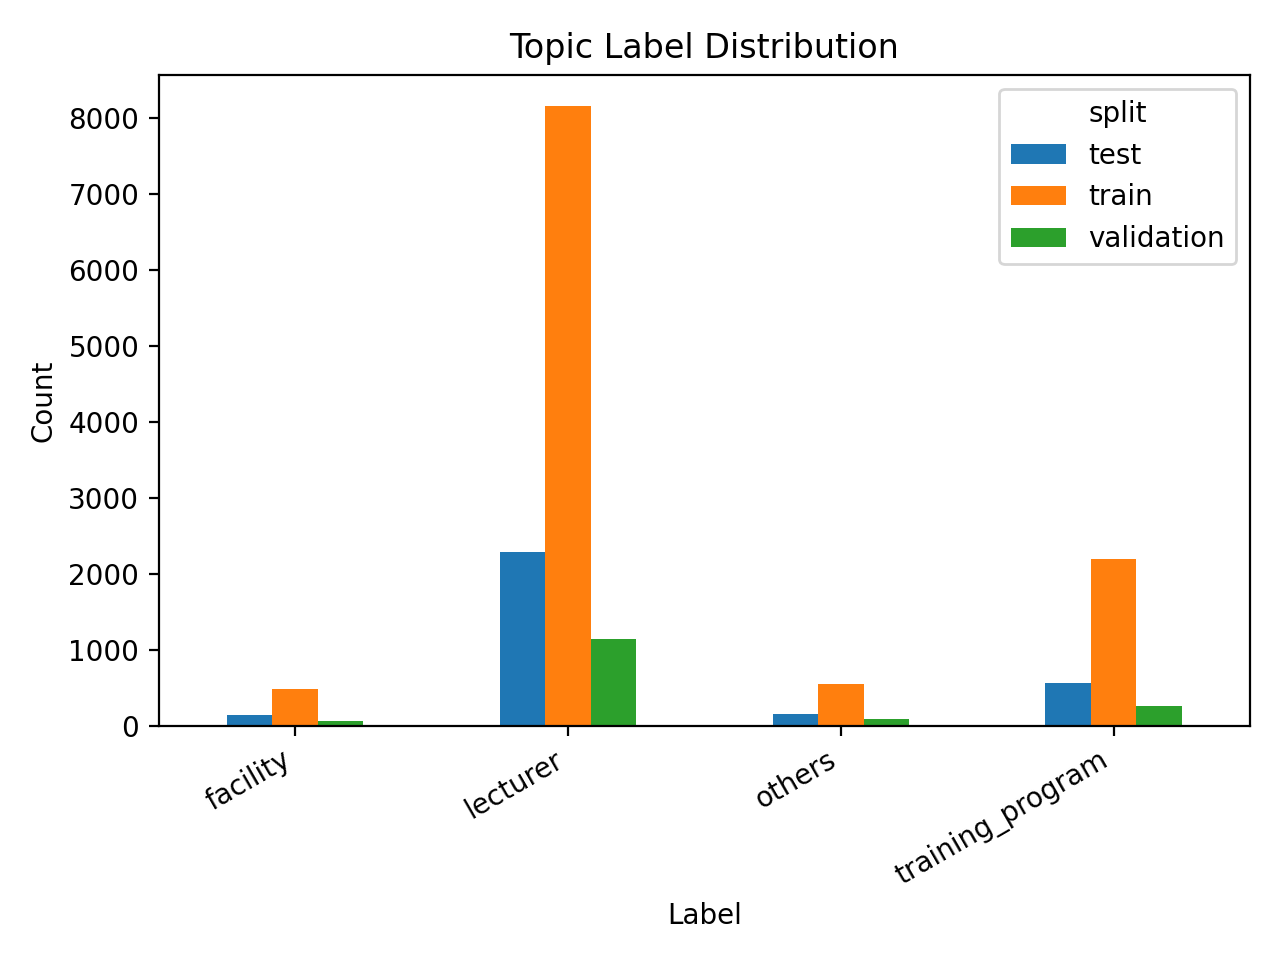

In [6]:
topic_dist = pd.read_csv(TABLES_DIR / "eda_label_distribution_topic.csv")
display(topic_dist)
display(Image(filename=str(FIGURES_DIR / "topic_distribution.png")))

### Nhận xét topic

Nếu `lecturer` chiếm đa số, model có thể đạt Accuracy cao dù dự đoán kém các lớp nhỏ như `facility` và `others`. Vì vậy topic classification phải ưu tiên Macro-F1.

In [7]:
topic_pivot = topic_dist.pivot(index="split", columns="label_name", values="percent")
display(topic_pivot)

if "lecturer" in topic_pivot.columns:
    lecturer_rates = topic_pivot["lecturer"]
    display(Markdown(f"Lecturer percent range: **{lecturer_rates.min():.2f}% - {lecturer_rates.max():.2f}%**"))

label_name,facility,lecturer,others,training_program
split,,,,
test,4.5799,72.3310,5.0221,18.0670
train,4.3497,71.4686,4.9186,19.2631
validation,4.4220,72.7100,6.0013,16.8667


Lecturer percent range: **71.47% - 72.71%**

## 6. Text length analysis

`whitespace_word_count` chỉ là độ dài theo khoảng trắng, không phải word segmentation tiếng Việt chuẩn. Tuy nhiên, nó vẫn hữu ích để hiểu độ dài phản hồi ở mức sơ bộ.

In [8]:
word_percentiles = pd.read_csv(TABLES_DIR / "text_length_percentiles.csv")
display(word_percentiles)

,scope,metric,percentile,value
0,test,whitespace_word_count,0,2.00
1,test,whitespace_word_count,25,8.00
2,test,whitespace_word_count,50,11.00
3,test,whitespace_word_count,75,17.00
4,test,whitespace_word_count,90,26.00
5,test,whitespace_word_count,95,34.00
6,test,whitespace_word_count,99,52.35
7,test,whitespace_word_count,100,98.00
8,train,whitespace_word_count,0,2.00
9,train,whitespace_word_count,25,8.00


## 7. PhoBERT subword length analysis

Mục tiêu: ước lượng độ dài input khi dùng tokenizer PhoBERT.

,scope,metric,percentile,value
0,test,phobert_subword_count,0,4.00
1,test,phobert_subword_count,25,10.00
2,test,phobert_subword_count,50,13.00
3,test,phobert_subword_count,75,20.00
4,test,phobert_subword_count,90,29.00
5,test,phobert_subword_count,95,37.00
6,test,phobert_subword_count,99,55.00
7,test,phobert_subword_count,100,102.00
8,train,phobert_subword_count,0,4.00
9,train,phobert_subword_count,25,10.00


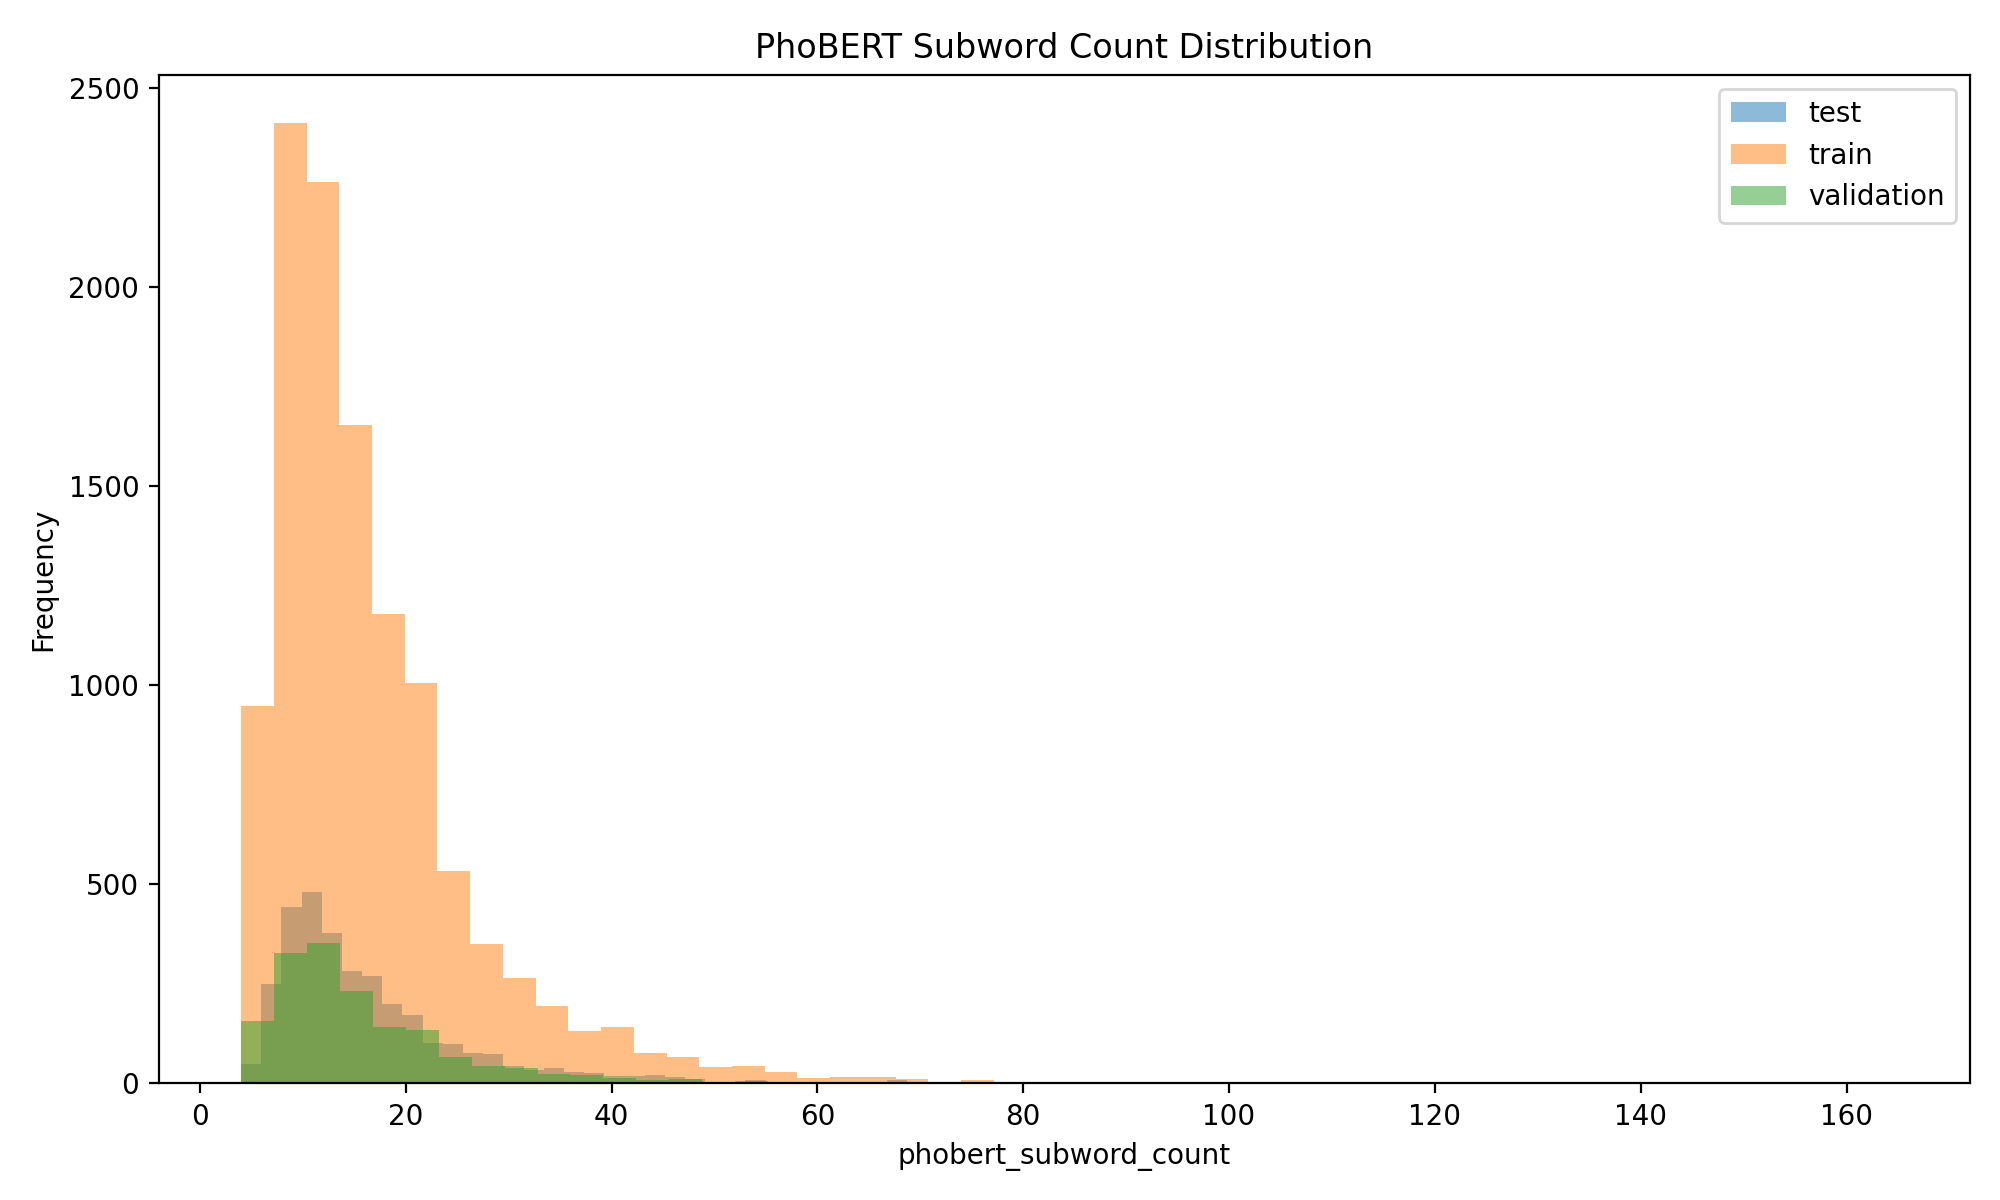

In [9]:
subword_percentiles = pd.read_csv(TABLES_DIR / "phobert_subword_length_percentiles.csv")
display(subword_percentiles)
display(Image(filename=str(FIGURES_DIR / "phobert_subword_count_distribution.png")))

## 8. max_length recommendation

`max_length` nên được chọn theo coverage, không chọn cảm tính.

In [10]:
max_length_df = pd.read_csv(TABLES_DIR / "max_length_recommendation.csv")
display(max_length_df)

# Gợi ý tự động: chọn candidate nhỏ nhất có coverage >= 99.9%
candidate = max_length_df.loc[max_length_df["coverage_percent"] >= 99.9].head(1)

if len(candidate) > 0:
    recommended = int(candidate.iloc[0]["max_length_candidate"])
else:
    recommended = int(max_length_df.sort_values("coverage_percent", ascending=False).iloc[0]["max_length_candidate"])

display(Markdown(f"Recommended max_length from >=99.9% coverage rule: **{recommended}**"))

# Với robustness evaluation, ta vẫn có thể chọn 128 để có buffer cho noisy text.
if recommended < 128:
    display(Markdown("For this project, choose **max_length = 128** to keep extra buffer for noisy text evaluation."))
else:
    display(Markdown(f"For this project, choose **max_length = {recommended}**."))

,max_length_candidate,covered_samples,total_samples,coverage_percent
0,64,16085,16175,99.4436
1,96,16164,16175,99.9320
2,128,16173,16175,99.9876
3,160,16173,16175,99.9876
4,192,16175,16175,100.0000
5,256,16175,16175,100.0000


Recommended max_length from >=99.9% coverage rule: **96**

For this project, choose **max_length = 128** to keep extra buffer for noisy text evaluation.

## 9. Kết luận Stage 2

Ghi nhận cho các giai đoạn sau:

```text
- Dataset không có text rỗng.
- Sentiment mất cân bằng, đặc biệt lớp neutral nhỏ.
- Topic mất cân bằng mạnh, lecturer chiếm đa số.
- Macro-F1 là metric chính cho cả hai task.
- Cần xem per-class F1 và confusion matrix, không chỉ Accuracy.
- Văn bản phần lớn ngắn.
- max_length=128 là lựa chọn an toàn cho PhoBERT vì gần như phủ toàn bộ dữ liệu sạch và có buffer cho noisy text.
```

Quyết định kỹ thuật:

```text
configs/phobert_sentiment.yaml → training.max_length = 128
configs/phobert_topic.yaml     → training.max_length = 128
```

Giai đoạn tiếp theo:

```text
Stage 3 — Baseline Models
```